In [ ]:
!pip install torchsummary
!pip install pytorch-gradcam

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import OneCycleLR
from torchsummary import summary

from pathlib import Path
from tqdm import tqdm
import random
import copy
import shutil
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from PIL import Image


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset

In [4]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from pathlib import Path

# Desired class mapping
desired_class_mapping = {
    'Fresh': 0,
    'Stage1': 1,
    'Stage-2': 2,
    'Stage-3': 3
}

# Training transformations with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),         # Horizontal flip
    transforms.RandomVerticalFlip(),           # Vertical flip
    transforms.RandomRotation(20),             # Random rotation ±20°
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color changes
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1), shear=5), # Slight affine transforms
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation and test transformations (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder('/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/train', transform=train_transform)
val_dataset = datasets.ImageFolder('/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/val', transform=val_test_transform)
test_dataset = datasets.ImageFolder('/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test', transform=val_test_transform)

# Update labels according to desired mapping
for dataset in [train_dataset, val_dataset, test_dataset]:
    dataset.samples = [(path, desired_class_mapping[Path(path).parent.name]) for path, _ in dataset.samples]
    dataset.targets = [s[1] for s in dataset.samples]
    dataset.class_to_idx = desired_class_mapping
    dataset.classes = list(desired_class_mapping.keys())

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Final counts - Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"New class mapping: {train_dataset.class_to_idx}")
print(f"Classes: {train_dataset.classes}")

Final counts - Train: 3203 | Val: 400 | Test: 401
New class mapping: {'Fresh': 0, 'Stage1': 1, 'Stage-2': 2, 'Stage-3': 3}
Classes: ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


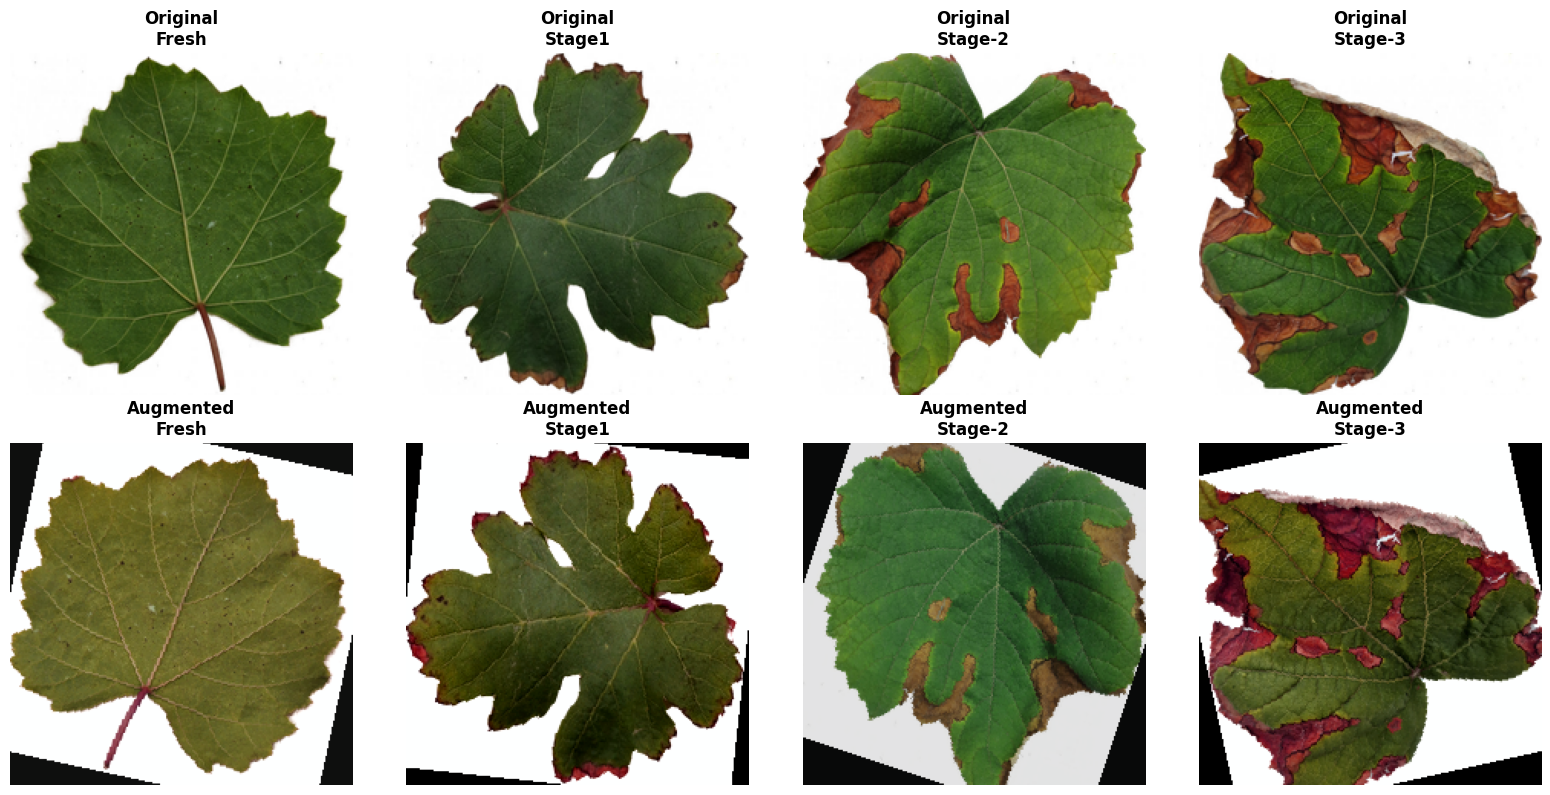

Class Distribution in Training Set:
Fresh: 800 images
Stage1: 800 images
Stage-2: 800 images
Stage-3: 803 images


In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import torch
from torchvision import transforms

# Example augmentation pipeline for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Set up the plot (2 rows: original vs augmented)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

class_names = list(desired_class_mapping.keys())

for idx, class_name in enumerate(class_names):
    # Find all samples belonging to this class
    class_samples = [(path, label) for path, label in train_dataset.samples
                     if label == desired_class_mapping[class_name]]

    # Pick a random sample
    random_sample_path, label = random.choice(class_samples)

    # Load original image
    img_orig = Image.open(random_sample_path).convert("RGB")
    axes[0, idx].imshow(img_orig)
    axes[0, idx].set_title(f'Original\n{class_name}', fontsize=12, fontweight='bold')
    axes[0, idx].axis('off')

    # Apply augmentations
    img_aug = train_transform(img_orig)
    img_aug_np = img_aug.permute(1, 2, 0).numpy()
    img_aug_np = img_aug_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # denormalize
    img_aug_np = img_aug_np.clip(0, 1)

    axes[1, idx].imshow(img_aug_np)
    axes[1, idx].set_title(f'Augmented\n{class_name}', fontsize=12, fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

# Print class distribution
print("Class Distribution in Training Set:")
for class_name in class_names:
    count = sum(1 for _, label in train_dataset.samples
                if label == desired_class_mapping[class_name])
    print(f"{class_name}: {count} images")

## SEModel75

In [ ]:
class SEPierceStageNet(nn.Module):
    """
    Lightweight Transfer Learning Model
    Optimized for small datasets (~4k images)
    """

    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()

        # Pretrained EfficientNet-B0
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")

        # Freeze most of the backbone
        for i, block in enumerate(self.backbone.features):
            if i < 6:  # freeze ~75%
                for param in block.parameters():
                    param.requires_grad = False

        # Lightweight SE attention (final features only)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(1280, 1280 // 16, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1280 // 16, 1280, 1),
            nn.Sigmoid()
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.se(x) * x
        x = self.classifier(x)
        return x


device = "cuda" if torch.cuda.is_available() else "cpu"
model = SEPierceStageNet(num_classes=4, dropout=0.3).to(device)
summary(model, input_size=(3, 224, 224), device=device)


## Training

In [ ]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1

output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
output_dir.mkdir(parents=True, exist_ok=True)

# Optimizer + Loss
learning_rate = 1e-3

backbone_params = []
classifier_params = []

for name, param in model.named_parameters():
    if "backbone" in name:
        backbone_params.append(param)
    else:
        classifier_params.append(param)

# Optimizer with different learning rates
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': learning_rate * 0.1},  # smaller lr for pretrained layers
    {'params': classifier_params, 'lr': learning_rate}        # original lr for classifier
], weight_decay=1e-4)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Scheduler
num_epochs = 20
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.4,   # slower warm-up
    anneal_strategy='cos'
)

# Mixed precision
scaler = torch.amp.GradScaler()

# Early stopping
patience = 5
best_val_acc = 0.0
patience_counter = 0

# Metric storage
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_precs, val_precs = [], []
train_recs, val_recs = [], []
train_f1s, val_f1s = [], []

for epoch in range(num_epochs):
    # training
    model.train()
    train_true, train_pred = [], []
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item() * images.size(0)
        train_true.extend(labels.cpu().numpy())
        train_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss /= len(train_loader.dataset)
    train_acc, train_prec, train_rec, train_f1 = compute_metrics(train_true, train_pred)

    # validation
    model.eval()
    val_true, val_pred = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  "):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_true.extend(labels.cpu().numpy())
            val_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc, val_prec, val_rec, val_f1 = compute_metrics(val_true, val_pred)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_precs.append(train_prec)
    val_precs.append(val_prec)
    train_recs.append(train_rec)
    val_recs.append(val_rec)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    # Print metrics
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")
    print(f"Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, output_dir / 'best_model.pth')
        print(f"New best model saved! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

# save history
history_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'train_accuracy': train_accs,
    'train_precision': train_precs,
    'train_recall': train_recs,
    'train_f1': train_f1s,
    'val_loss': val_losses,
    'val_accuracy': val_accs,
    'val_precision': val_precs,
    'val_recall': val_recs,
    'val_f1': val_f1s
})
history_csv_path = output_dir / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved to: {history_csv_path}")

# load best saved model
checkpoint = torch.load(output_dir / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_true, test_pred = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device):
            outputs = model(images)

        test_true.extend(labels.cpu().numpy())
        test_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

test_acc, test_prec, test_rec, test_f1 = compute_metrics(test_true, test_pred)

# Save test results
test_results_df = pd.DataFrame({
    'metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'value': [test_acc, test_prec, test_rec, test_f1]
})
test_csv_path = output_dir / 'test_results.csv'
test_results_df.to_csv(test_csv_path, index=False)
print(f"Test results saved to: {test_csv_path}")

# Comprehensive summary
summary_df = pd.DataFrame({
    'Dataset': ['Train (Final)', 'Validation (Best)', 'Test'],
    'Accuracy': [train_accs[-1], best_val_acc, test_acc],
    'Precision': [train_precs[-1], val_precs[val_accs.index(best_val_acc)], test_prec],
    'Recall': [train_recs[-1], val_recs[val_accs.index(best_val_acc)], test_rec],
    'F1 Score': [train_f1s[-1], val_f1s[val_accs.index(best_val_acc)], test_f1]
})
summary_csv_path = output_dir / 'model_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"Model summary saved to: {summary_csv_path}")

Epoch 1/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1/20 [Val]  : 100%|██████████| 13/13 [01:36<00:00,  7.45s/it]


Epoch 1/20
Train - Loss: 1.2815 | Acc: 0.5120 | Prec: 0.5154 | Rec: 0.5118 | F1: 0.4945
Val   - Loss: 1.0775 | Acc: 0.6325 | Prec: 0.6610 | Rec: 0.6325 | F1: 0.5872
New best model saved! Val Acc: 0.6325


Epoch 2/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 2/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

Epoch 2/20
Train - Loss: 0.9175 | Acc: 0.6850 | Prec: 0.6768 | Rec: 0.6848 | F1: 0.6781
Val   - Loss: 0.8849 | Acc: 0.7100 | Prec: 0.7313 | Rec: 0.7100 | F1: 0.7016
New best model saved! Val Acc: 0.7100


Epoch 3/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 3/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

...

Epoch 19/20
Train - Loss: 0.4481 | Acc: 0.9507 | Prec: 0.9508 | Rec: 0.9507 | F1: 0.9507
Val   - Loss: 0.5057 | Acc: 0.9150 | Prec: 0.9149 | Rec: 0.9150 | F1: 0.9145


Epoch 20/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 20/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if

Epoch 20/20
Train - Loss: 0.4428 | Acc: 0.9557 | Prec: 0.9556 | Rec: 0.9557 | F1: 0.9556
Val   - Loss: 0.5115 | Acc: 0.9100 | Prec: 0.9113 | Rec: 0.9100 | F1: 0.9095
Training history saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/training_history.csv


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 13/13 [01:39<00:00,  7.64s/it]


Test results saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/test_results.csv
Model summary saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/model_summary.csv


In [ ]:
# Final metrics for training (last epoch)
final_train_metrics = {
    'Accuracy': train_accs[-1],
    'Precision': train_precs[-1],
    'Recall': train_recs[-1],
    'F1 Score': train_f1s[-1]
}

# Best validation metrics
best_val_idx = val_accs.index(best_val_acc)
best_val_metrics = {
    'Accuracy': val_accs[best_val_idx],
    'Precision': val_precs[best_val_idx],
    'Recall': val_recs[best_val_idx],
    'F1 Score': val_f1s[best_val_idx]
}

# Test metrics
test_metrics = {
    'Accuracy': test_acc,
    'Precision': test_prec,
    'Recall': test_rec,
    'F1 Score': test_f1
}

# Print final metrics
print("\nFinal Model Metrics:\n")
print("Training (Last Epoch):")
for k, v in final_train_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nValidation (Best Epoch):")
for k, v in best_val_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nTest Set:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Optional: save to CSV
summary_df = pd.DataFrame({
    'Dataset': ['Train (Final)', 'Validation (Best)', 'Test'],
    'Accuracy': [final_train_metrics['Accuracy'], best_val_metrics['Accuracy'], test_metrics['Accuracy']],
    'Precision': [final_train_metrics['Precision'], best_val_metrics['Precision'], test_metrics['Precision']],
    'Recall': [final_train_metrics['Recall'], best_val_metrics['Recall'], test_metrics['Recall']],
    'F1 Score': [final_train_metrics['F1 Score'], best_val_metrics['F1 Score'], test_metrics['F1 Score']]
})

summary_csv_path = output_dir / 'model_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"Model summary saved to: {summary_csv_path}")


Final Model Metrics:

Training (Last Epoch):
  Accuracy: 0.9557
  Precision: 0.9556
  Recall: 0.9557
  F1 Score: 0.9556

Validation (Best Epoch):
  Accuracy: 0.9225
  Precision: 0.9224
  Recall: 0.9225
  F1 Score: 0.9222

Test Set:
  Accuracy: 0.9526
  Precision: 0.9526
  Recall: 0.9525
  F1 Score: 0.9524
Model summary saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/model_summary.csv


In [ ]:
# Set theme
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

# Load training history
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
history_path = output_dir / 'training_history.csv'
history_df = pd.read_csv(history_path)

# Colors for metrics
colors = {
    'loss': ('#1f77b4', '#ff7f0e'),
    'accuracy': ('#2ca02c', '#ff7f0e'),
    'precision': ('#9467bd', '#ff7f0e'),
    'recall': ('#e377c2', '#ff7f0e'),
    'f1': ('#17becf', '#ff7f0e')
}

# Function to create and save a single metric plot
def save_metric_plot(train_col, val_col, title, ylabel, train_color, val_color, filename):
    plt.figure(figsize=(8, 6))
    plt.plot(history_df['epoch'], history_df[train_col], label='Train', color=train_color,
             linewidth=2, marker='o', markersize=4, alpha=0.8)
    plt.plot(history_df['epoch'], history_df[val_col], label='Validation', color=val_color,
             linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
    plt.fill_between(history_df['epoch'], history_df[train_col], history_df[val_col],
                     color='gray', alpha=0.1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)
    plt.close()
    print(f"{title} saved as {filename}")

# Generate separate plots
save_metric_plot('train_loss', 'val_loss', 'Loss over Epochs', 'Loss', *colors['loss'], 'loss_plot.png')
save_metric_plot('train_accuracy', 'val_accuracy', 'Accuracy over Epochs', 'Accuracy', *colors['accuracy'], 'accuracy_plot.png')
save_metric_plot('train_precision', 'val_precision', 'Precision over Epochs', 'Precision', *colors['precision'], 'precision_plot.png')
save_metric_plot('train_recall', 'val_recall', 'Recall over Epochs', 'Recall', *colors['recall'], 'recall_plot.png')
save_metric_plot('train_f1', 'val_f1', 'F1 Score over Epochs', 'F1 Score', *colors['f1'], 'f1_plot.png')

# Combined metrics plot (train vs validation)
plt.figure(figsize=(8, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1']
combined_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    plt.plot(history_df['epoch'], history_df[f'val_{metric}'], color=combined_colors[i],
             linewidth=2, label=f'Val {metric.capitalize()}', marker='o')
    plt.plot(history_df['epoch'], history_df[f'train_{metric}'], color=combined_colors[i],
             linewidth=1, linestyle='--', alpha=0.6, label=f'Train {metric.capitalize()}')

plt.title('All Metrics Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / 'all_metrics_plot.png', dpi=300)
plt.close()
print("All metrics comparison plot saved as all_metrics_plot.png")


Loss over Epochs saved as loss_plot.png
Accuracy over Epochs saved as accuracy_plot.png
Precision over Epochs saved as precision_plot.png
Recall over Epochs saved as recall_plot.png
F1 Score over Epochs saved as f1_plot.png
All metrics comparison plot saved as all_metrics_plot.png


## Testing

In [ ]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the best saved model
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
checkpoint_path = output_dir / 'best_model.pth'

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Best model loaded from epoch {checkpoint['epoch'] + 1} with validation accuracy: {checkpoint['val_acc']:.4f}")

# Lists to store results
image_paths_list = []
true_labels_list = []
predicted_labels_list = []
true_classes_list = []
predicted_classes_list = []
confidence_scores_list = []

# Get class names
class_names = test_dataset.classes

# Make predictions on test data
with torch.no_grad():  # Disable gradient computation for inference
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Making predictions")):
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions and confidence scores
        probabilities = torch.softmax(outputs, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

        # Get image paths for this batch
        start_idx = batch_idx * test_loader.batch_size
        end_idx = min(start_idx + len(labels), len(test_dataset.samples))

        for i in range(len(labels)):
            # Get the actual index in the dataset
            idx = start_idx + i

            # Get image path
            image_path = test_dataset.samples[idx][0]

            # Get true and predicted labels
            true_label = labels[i].item()
            predicted_label = predictions[i].item()

            # Get class names
            true_class = class_names[true_label]
            predicted_class = class_names[predicted_label]

            # Get confidence score
            confidence = confidence_scores[i].item()

            # Append to lists
            image_paths_list.append(image_path)
            true_labels_list.append(true_label)
            predicted_labels_list.append(predicted_label)
            true_classes_list.append(true_class)
            predicted_classes_list.append(predicted_class)
            confidence_scores_list.append(confidence)

print(f"Total predictions made: {len(image_paths_list)}")

# Create DataFrame from lists
results_df = pd.DataFrame({
    'image_path': image_paths_list,
    'true_label': true_labels_list,
    'predicted_label': predicted_labels_list,
    'true_class': true_classes_list,
    'predicted_class': predicted_classes_list,
    'confidence': confidence_scores_list
})

# Save results to CSV
results_csv_path = output_dir / 'test_predictions.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"Predictions saved to: {results_csv_path}")
print(f"Total records: {len(results_df)}")

# Show sample of predictions
print("results:")
print(results_df.head(10).to_string())

# Calculate and display basic statistics
correct_predictions = (results_df['true_label'] == results_df['predicted_label']).sum()
total_predictions = len(results_df)
test_accuracy = correct_predictions / total_predictions


print(f"Total test samples: {total_predictions}")
print(f"Correct predictions: {correct_predictions}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Incorrect predictions: {total_predictions - correct_predictions}")

# Save accuracy to a simple text file
accuracy_file = output_dir / 'test_accuracy.txt'
with open(accuracy_file, 'w') as f:
    f.write(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")
    f.write(f"Correct/Total: {correct_predictions}/{total_predictions}\n")
print(f"Accuracy saved to: {accuracy_file}")

Using device: cuda
Best model loaded from epoch 17 with validation accuracy: 0.9225


Making predictions:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Making predictions: 100%|██████████| 13/13 [00:02<00:00,  5.62it/s]


Total predictions made: 401
Predictions saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/test_predictions.csv
Total records: 401
results:
                                                                      image_path  true_label  predicted_label true_class predicted_class  confidence
0  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_125.png           0                0      Fresh           Fresh    0.846823
1  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_133.png           0                0      Fresh           Fresh    0.942309
2  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_138.png           0                0      Fresh           Fresh    0.869711
3  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_147.png           0                0      Fresh           Fresh    0.931695
4  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_148.png           0    

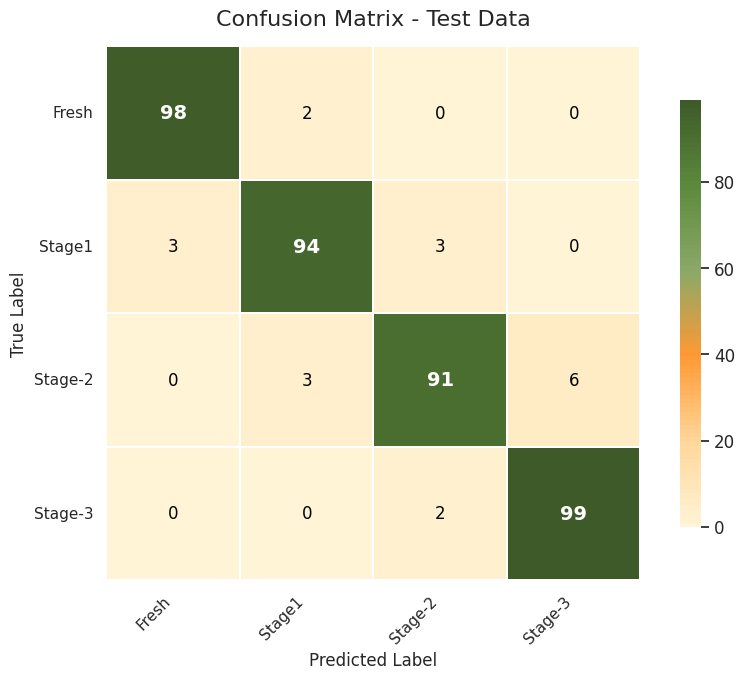

In [ ]:
# Clean professional style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Class names
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

# Compute confusion matrix
cm = confusion_matrix(test_true, test_pred)

# Create custom colormap with yellow and green tones (darker)
colors = ['#FFF4D6', '#FFD699', '#FF9933', '#8BA968', '#5C8A3D', '#3D5A28']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_yellow_green', colors, N=n_bins)

# Create figure
plt.figure(figsize=(9, 7), facecolor='white')
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=cmap,
    cbar=True,
    xticklabels=classes,
    yticklabels=classes,
    linewidths=1.2,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

# Style the text annotations
for i, text in enumerate(ax.texts):
    row = i // cm.shape[1]
    col = i % cm.shape[1]
    if row == col:  # diagonal
        text.set_color('white')
        text.set_fontweight('bold')
        text.set_fontsize(14)
    else:  # off-diagonal
        text.set_color('black')
        text.set_fontweight('normal')
        text.set_fontsize(12)

# Title and labels
plt.title('Confusion Matrix - Test Data', fontsize=16, fontweight='normal', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='normal')
plt.ylabel('True Label', fontsize=12, fontweight='normal')

# Tick styling
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(output_dir / "confusion_matrix_test.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

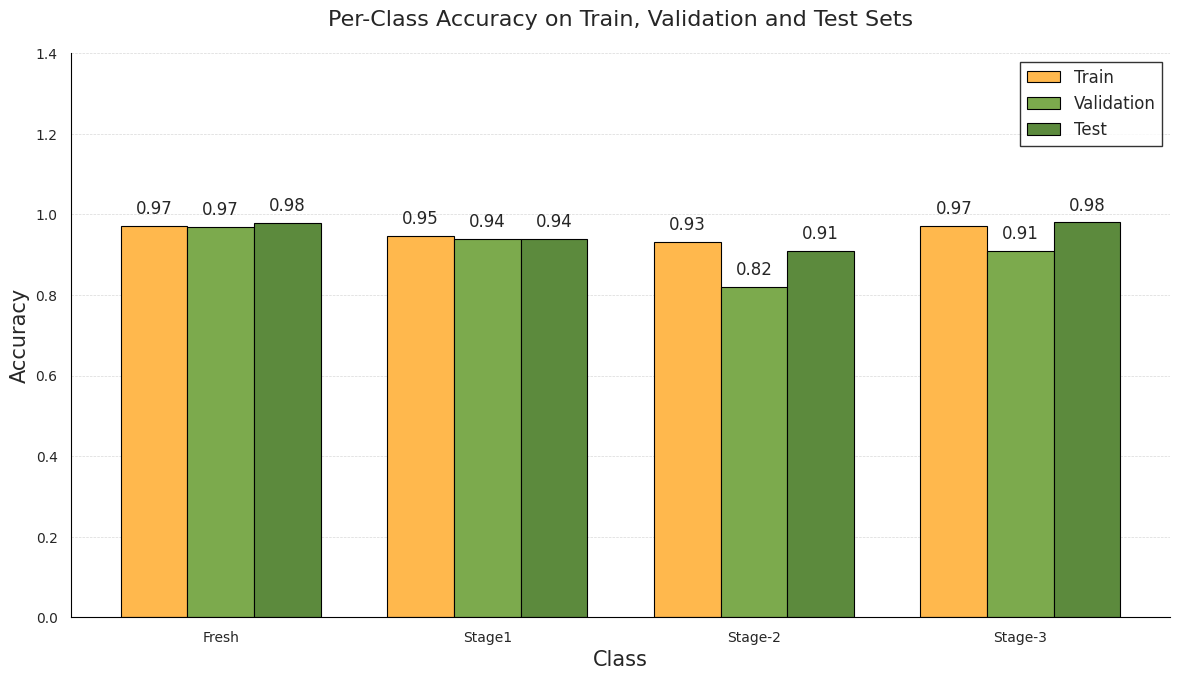

In [ ]:
# Clean professional style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Class names
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

# Compute confusion matrices
cm_train = confusion_matrix(train_true, train_pred)
cm_val = confusion_matrix(val_true, val_pred)
cm_test = confusion_matrix(test_true, test_pred)

# Per-class accuracy for each set
train_acc = cm_train.diagonal() / cm_train.sum(axis=1)
val_acc = cm_val.diagonal() / cm_val.sum(axis=1)
test_acc = cm_test.diagonal() / cm_test.sum(axis=1)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

# Bar positioning
x = np.arange(len(classes))
width = 0.25

# Create bars with colors from reference image
bars1 = ax.bar(x - width, train_acc, width, label='Train',
               color='#FFB84D', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x, val_acc, width, label='Validation',
               color='#7CAA4D', edgecolor='black', linewidth=0.8)
bars3 = ax.bar(x + width, test_acc, width, label='Test',
               color='#5C8A3D', edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=12, fontweight='normal')

# Title and labels
ax.set_title('Per-Class Accuracy on Train, Validation and Test Sets',
             fontsize=16, fontweight='normal', pad=20)
ax.set_ylabel('Accuracy', fontsize=15, fontweight='normal')
ax.set_xlabel('Class', fontsize=15, fontweight='normal')

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)

# Y-axis
ax.set_ylim(0, 1.2)
ax.set_yticks(np.arange(0, 1.5, 0.2))
ax.tick_params(axis='both', labelsize=10)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.8)

# Legend
ax.legend(loc='upper right', frameon=True, fontsize=12,
          edgecolor='black', fancybox=False)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig(output_dir / 'per_class_accuracy_all_sets.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

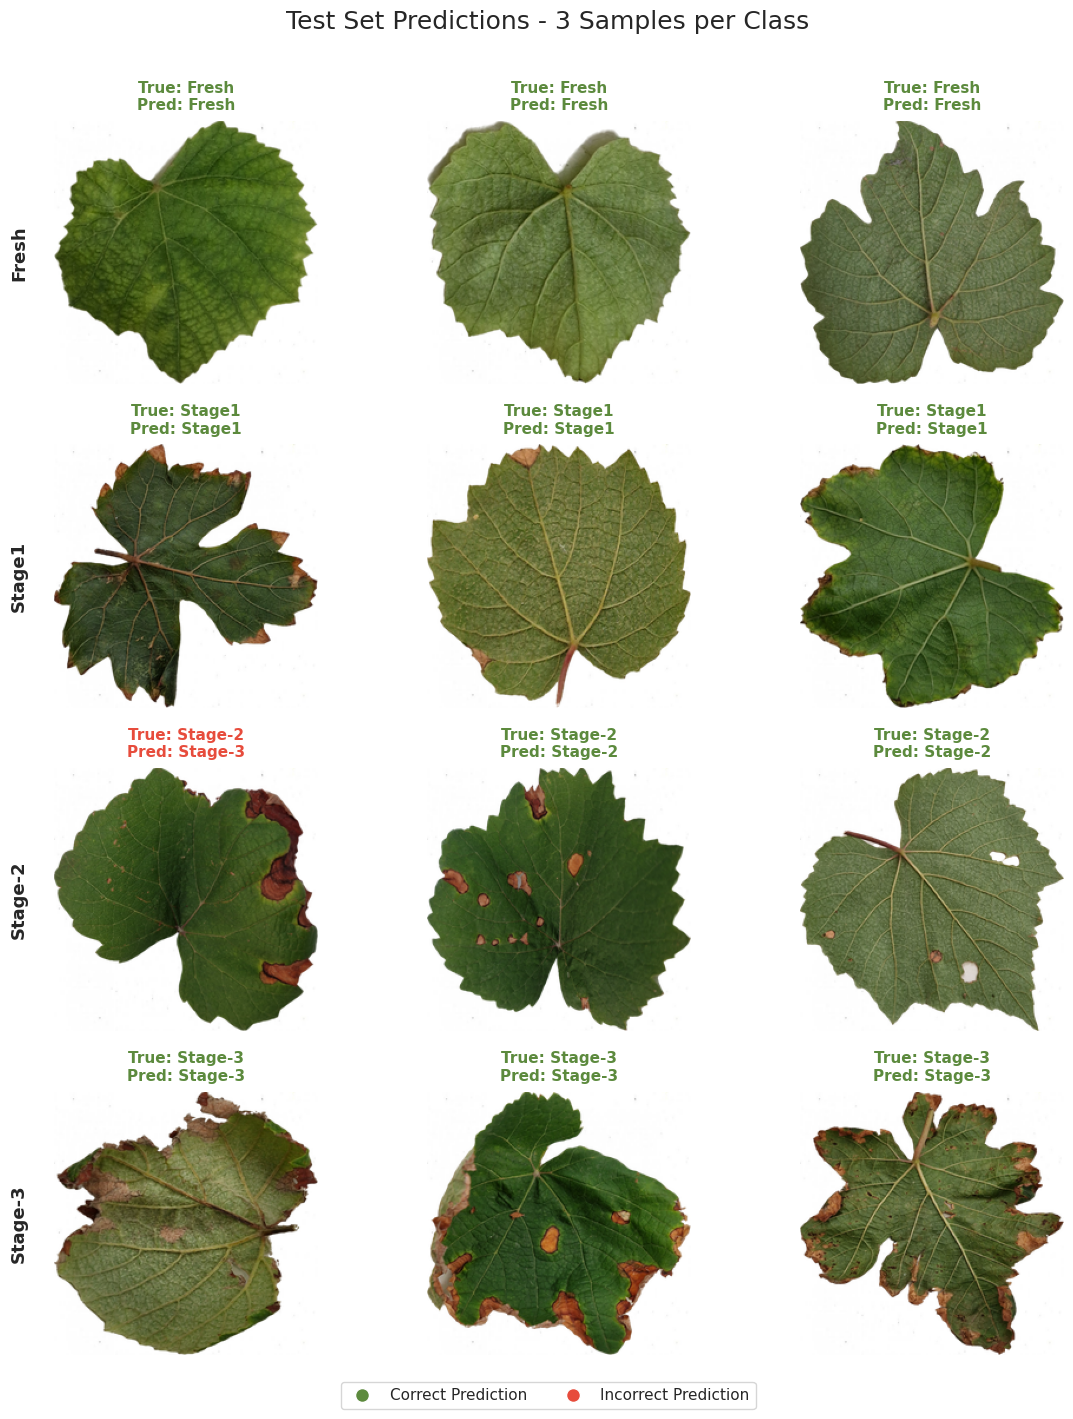

In [ ]:
# Clean professional style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Class names and mapping
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']
class_mapping = {'Fresh': 0, 'Stage1': 1, 'Stage-2': 2, 'Stage-3': 3}

# Set up the plot - 4 rows (classes) x 3 columns (samples)
fig, axes = plt.subplots(4, 3, figsize=(12, 14), facecolor='white')
fig.suptitle('Test Set Predictions - 3 Samples per Class',
             fontsize=18, fontweight='normal', y=0.995)

# For each class
for row_idx, class_name in enumerate(classes):
    # Find all samples belonging to this class in test set
    class_samples = [(path, label) for path, label in test_dataset.samples
                     if label == class_mapping[class_name]]

    # Pick 3 random samples
    selected_samples = random.sample(class_samples, min(3, len(class_samples)))

    for col_idx, (sample_path, true_label) in enumerate(selected_samples):
        ax = axes[row_idx, col_idx]

        # Load the image
        img = Image.open(sample_path)
        ax.imshow(img)

        # Find the prediction for this sample
        # Get the index of this sample in test_dataset
        sample_idx = test_dataset.samples.index((sample_path, true_label))
        pred_label = test_pred[sample_idx]

        # Determine if prediction is correct
        is_correct = true_label == pred_label
        title_color = '#5C8A3D' if is_correct else '#E74C3C'

        # Get class names for labels
        true_class = classes[true_label]
        pred_class = classes[pred_label]

        # Add title with true and predicted labels
        title = f'True: {true_class}\nPred: {pred_class}'
        ax.set_title(title, fontsize=11, fontweight='bold',
                    color=title_color, pad=8)

        # Remove axis
        ax.axis('off')

        # Add class label on the left for first column
        if col_idx == 0:
            ax.text(-0.1, 0.5, class_name, transform=ax.transAxes,
                   fontsize=13, fontweight='bold', rotation=90,
                   va='center', ha='right')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#5C8A3D',
               markersize=10, label='Correct Prediction'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C',
               markersize=10, label='Incorrect Prediction')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
          fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.01))

# Adjust layout
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

# Save figure
plt.savefig(output_dir / 'test_samples_visualization.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Grad-Cam

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


device = "cuda" if torch.cuda.is_available() else "cpu"
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")

# model
model = SEPierceStageNet(num_classes=4, dropout=0.5).to(device)
checkpoint = torch.load(output_dir / "best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# target layer
target_layers = [model.backbone.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Classes
class_names = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

#  one image from each class
predicted_class_images = {}
predicted_class_info = {}

all_indices = list(range(len(test_dataset)))
random.shuffle(all_indices)

for idx in all_indices:
    img_tensor, true_label = test_dataset[idx]
    img_tensor_batch = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor_batch)
        pred_label = output.argmax(dim=1).item()

    if pred_label not in predicted_class_images:
        predicted_class_images[pred_label] = (img_tensor, img_tensor_batch)
        predicted_class_info[pred_label] = (true_label, pred_label)

    if len(predicted_class_images) == 4:
        break

# plot images
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, pred_class in enumerate(sorted(predicted_class_images.keys())):
    img_tensor, img_tensor_batch = predicted_class_images[pred_class]
    true_label, pred_label = predicted_class_info[pred_class]

    # Grad-CAM
    grayscale_cam = cam(input_tensor=img_tensor_batch, targets=None)[0]

    # tensor to image
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Grad-CAM overlay
    cam_overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # Titles
    label_text = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(label_text, fontsize=18, pad=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_overlay)
    axes[1, i].set_title("Grad-CAM Overlay", fontsize=18, pad=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Pretrained Models

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

NUM_CLASSES = 4
EPOCHS = 20
LEARNING_RATE = 0.001
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

def build_efficientnet_b0(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model.to(device)

def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

    return model.to(device)

def train_model(model, train_loader, val_loader, model_name, num_epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\n{model_name} - Epoch {epoch+1}/{num_epochs}')
        print('-' * 60)

        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc='Training'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)

        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validation'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = running_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.cpu().numpy())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.cpu().numpy())

        print(f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
        print(f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        scheduler.step(epoch_val_loss)

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f'{model_name}_best_model.pth')
            print(f'Best model saved with accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

efficientnet_model = build_efficientnet_b0()
efficientnet_model, efficientnet_history = train_model(
    efficientnet_model, train_loader, val_loader, 'EfficientNetB0'
)

resnet_model = build_resnet50()
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader, 'ResNet50'
)

print("\nEfficientNet-B0 Results:")
efficientnet_true, efficientnet_pred = evaluate_model(efficientnet_model, test_loader)
efficientnet_acc = np.mean(efficientnet_true == efficientnet_pred)
efficientnet_precision = precision_score(efficientnet_true, efficientnet_pred, average='weighted')
efficientnet_recall = recall_score(efficientnet_true, efficientnet_pred, average='weighted')
efficientnet_f1 = f1_score(efficientnet_true, efficientnet_pred, average='weighted')

print(f"Test Accuracy: {efficientnet_acc:.4f}")
print(f"Precision: {efficientnet_precision:.4f}")
print(f"Recall: {efficientnet_recall:.4f}")
print(f"F1-Score: {efficientnet_f1:.4f}")
print("\nClassification Report:")
print(classification_report(efficientnet_true, efficientnet_pred, target_names=classes))

print("\nResNet50 Results:")
resnet_true, resnet_pred = evaluate_model(resnet_model, test_loader)
resnet_acc = np.mean(resnet_true == resnet_pred)
resnet_precision = precision_score(resnet_true, resnet_pred, average='weighted')
resnet_recall = recall_score(resnet_true, resnet_pred, average='weighted')
resnet_f1 = f1_score(resnet_true, resnet_pred, average='weighted')

print(f"Test Accuracy: {resnet_acc:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall: {resnet_recall:.4f}")
print(f"F1-Score: {resnet_f1:.4f}")
print("\nClassification Report:")
print(classification_report(resnet_true, resnet_pred, target_names=classes))

Using device: cuda

EfficientNetB0 - Epoch 1/20
------------------------------------------------------------


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.97it/s]


Train Loss: 1.0699 Acc: 0.5270
Val Loss: 0.8057 Acc: 0.6675
Best model saved with accuracy: 0.6675

EfficientNetB0 - Epoch 2/20
------------------------------------------------------------


Validation: 100%|██████████| 13/13 [00:04<00:00,  3.02it/s]


Train Loss: 0.8964 Acc: 0.6044
Val Loss: 0.7346 Acc: 0.6850
Best model saved with accuracy: 0.6850

EfficientNetB0 - Epoch 3/20
------------------------------------------------------------


...

Train Loss: 0.8636 Acc: 0.6238
Val Loss: 0.7266 Acc: 0.6775

EfficientNet-B0 Results:


Testing: 100%|██████████| 13/13 [00:02<00:00,  5.82it/s]


Test Accuracy: 0.7307
Precision: 0.7290
Recall: 0.7307
F1-Score: 0.7261

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.85      0.85      0.85       100
      Stage1       0.64      0.76      0.69       100
     Stage-2       0.64      0.49      0.55       100
     Stage-3       0.79      0.82      0.81       101

    accuracy                           0.73       401
   macro avg       0.73      0.73      0.73       401
weighted avg       0.73      0.73      0.73       401


ResNet50 Results:


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 13/13 [00:02<00:00,  4.39it/s]

Test Accuracy: 0.6534
Precision: 0.6816
Recall: 0.6534
F1-Score: 0.6563

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.88      0.61      0.72       100
      Stage1       0.49      0.69      0.57       100
     Stage-2       0.55      0.47      0.51       100
     Stage-3       0.80      0.84      0.82       101

    accuracy                           0.65       401
   macro avg       0.68      0.65      0.66       401
weighted avg       0.68      0.65      0.66       401



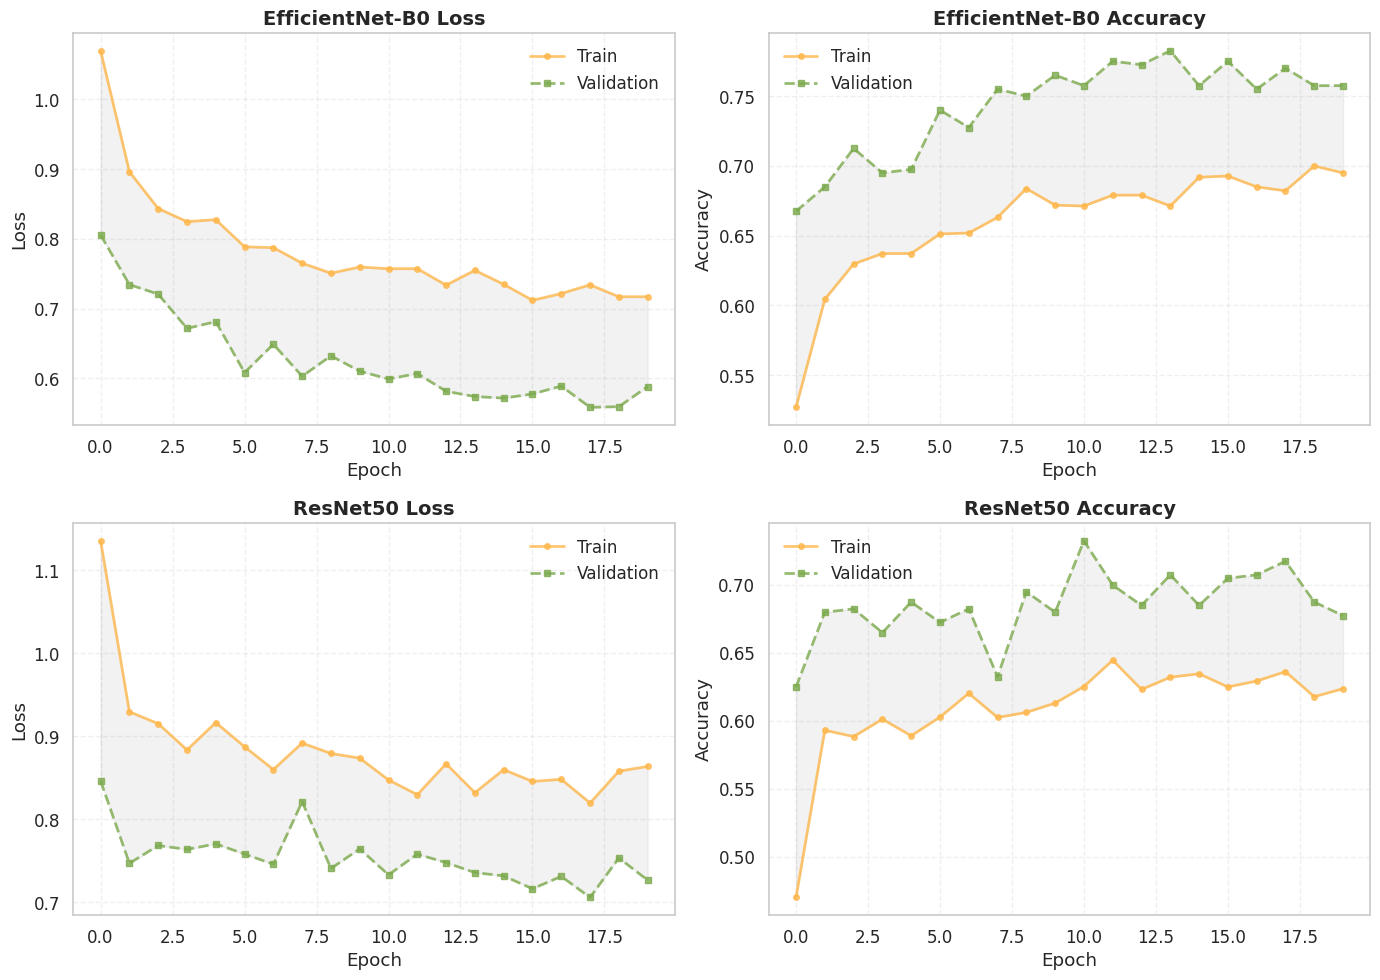

Plot saved as 'models_training_comparison.png'

Final Results:
EfficientNet-B0 - Final Train Acc: 0.6950, Val Acc: 0.7575
ResNet50 - Final Train Acc: 0.6238, Val Acc: 0.6775


In [ ]:
# Set theme
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

# Set font to sans-serif
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

# EfficientNet-B0 Loss
axes[0, 0].plot(efficientnet_history['train_loss'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0, 0].plot(efficientnet_history['val_loss'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[0, 0].fill_between(range(len(efficientnet_history['train_loss'])),
                        efficientnet_history['train_loss'],
                        efficientnet_history['val_loss'],
                        color='gray', alpha=0.1)
axes[0, 0].set_title('EfficientNet-B0 Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# EfficientNet-B0 Accuracy
axes[0, 1].plot(efficientnet_history['train_acc'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0, 1].plot(efficientnet_history['val_acc'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[0, 1].fill_between(range(len(efficientnet_history['train_acc'])),
                        efficientnet_history['train_acc'],
                        efficientnet_history['val_acc'],
                        color='gray', alpha=0.1)
axes[0, 1].set_title('EfficientNet-B0 Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# ResNet50 Loss
axes[1, 0].plot(resnet_history['train_loss'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[1, 0].plot(resnet_history['val_loss'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[1, 0].fill_between(range(len(resnet_history['train_loss'])),
                        resnet_history['train_loss'],
                        resnet_history['val_loss'],
                        color='gray', alpha=0.1)
axes[1, 0].set_title('ResNet50 Loss', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(frameon=False)
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# ResNet50 Accuracy
axes[1, 1].plot(resnet_history['train_acc'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[1, 1].plot(resnet_history['val_acc'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[1, 1].fill_between(range(len(resnet_history['train_acc'])),
                        resnet_history['train_acc'],
                        resnet_history['val_acc'],
                        color='gray', alpha=0.1)
axes[1, 1].set_title('ResNet50 Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(frameon=False)
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('models_training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'models_training_comparison.png'")
print("\nFinal Results:")
print(f"EfficientNet-B0 - Final Train Acc: {efficientnet_history['train_acc'][-1]:.4f}, Val Acc: {efficientnet_history['val_acc'][-1]:.4f}")
print(f"ResNet50 - Final Train Acc: {resnet_history['train_acc'][-1]:.4f}, Val Acc: {resnet_history['val_acc'][-1]:.4f}")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

NUM_CLASSES = 4
EPOCHS = 20
LEARNING_RATE = 0.001
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

def build_efficientnet_b0_freeze50(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(pretrained=True)

    for i, block in enumerate(model.features):
        if i < 4:
            for param in block.parameters():
                param.requires_grad = False

    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model.to(device)

def build_efficientnet_b0_freeze75(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(pretrained=True)

    for i, block in enumerate(model.features):
        if i < 6:
            for param in block.parameters():
                param.requires_grad = False

    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model.to(device)

def train_model(model, train_loader, val_loader, model_name, num_epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\n{model_name} - Epoch {epoch+1}/{num_epochs}')
        print('-' * 60)

        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc='Training'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)

        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validation'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = running_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.cpu().numpy())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.cpu().numpy())

        print(f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
        print(f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        scheduler.step(epoch_val_loss)

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f'{model_name}_best_model.pth')
            print(f'Best model saved with accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

efficientnet_50_model = build_efficientnet_b0_freeze50()
efficientnet_50_model, efficientnet_50_history = train_model(
    efficientnet_50_model, train_loader, val_loader, 'EfficientNetB0_Freeze50'
)

efficientnet_75_model = build_efficientnet_b0_freeze75()
efficientnet_75_model, efficientnet_75_history = train_model(
    efficientnet_75_model, train_loader, val_loader, 'EfficientNetB0_Freeze75'
)

print("\nEfficientNet-B0 (50% Frozen) Results:")
efficientnet_50_true, efficientnet_50_pred = evaluate_model(efficientnet_50_model, test_loader)
efficientnet_50_acc = np.mean(efficientnet_50_true == efficientnet_50_pred)
efficientnet_50_precision = precision_score(efficientnet_50_true, efficientnet_50_pred, average='weighted')
efficientnet_50_recall = recall_score(efficientnet_50_true, efficientnet_50_pred, average='weighted')
efficientnet_50_f1 = f1_score(efficientnet_50_true, efficientnet_50_pred, average='weighted')

print(f"Test Accuracy: {efficientnet_50_acc:.4f}")
print(f"Precision: {efficientnet_50_precision:.4f}")
print(f"Recall: {efficientnet_50_recall:.4f}")
print(f"F1-Score: {efficientnet_50_f1:.4f}")
print("\nClassification Report:")
print(classification_report(efficientnet_50_true, efficientnet_50_pred, target_names=classes))

print("\nEfficientNet-B0 (75% Frozen) Results:")
efficientnet_75_true, efficientnet_75_pred = evaluate_model(efficientnet_75_model, test_loader)
efficientnet_75_acc = np.mean(efficientnet_75_true == efficientnet_75_pred)
efficientnet_75_precision = precision_score(efficientnet_75_true, efficientnet_75_pred, average='weighted')
efficientnet_75_recall = recall_score(efficientnet_75_true, efficientnet_75_pred, average='weighted')
efficientnet_75_f1 = f1_score(efficientnet_75_true, efficientnet_75_pred, average='weighted')

print(f"Test Accuracy: {efficientnet_75_acc:.4f}")
print(f"Precision: {efficientnet_75_precision:.4f}")
print(f"Recall: {efficientnet_75_recall:.4f}")
print(f"F1-Score: {efficientnet_75_f1:.4f}")
print("\nClassification Report:")
print(classification_report(efficientnet_75_true, efficientnet_75_pred, target_names=classes))

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 195MB/s]



EfficientNetB0_Freeze50 - Epoch 1/20
------------------------------------------------------------


Validation: 100%|██████████| 13/13 [01:31<00:00,  7.04s/it]


Train Loss: 0.8653 Acc: 0.6416
Val Loss: 0.6140 Acc: 0.7175
Best model saved with accuracy: 0.7175

EfficientNetB0_Freeze50 - Epoch 2/20
------------------------------------------------------------


...

Train Loss: 0.3011 Acc: 0.8901
Val Loss: 0.3138 Acc: 0.8775

EfficientNet-B0 (50% Frozen) Results:


Testing: 100%|██████████| 13/13 [01:32<00:00,  7.13s/it]


Test Accuracy: 0.8953
Precision: 0.8951
Recall: 0.8953
F1-Score: 0.8939

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.89      1.00      0.94       100
      Stage1       0.88      0.88      0.88       100
     Stage-2       0.87      0.79      0.83       100
     Stage-3       0.94      0.91      0.92       101

    accuracy                           0.90       401
   macro avg       0.89      0.90      0.89       401
weighted avg       0.90      0.90      0.89       401


EfficientNet-B0 (75% Frozen) Results:


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 13/13 [00:02<00:00,  5.82it/s]

Test Accuracy: 0.8853
Precision: 0.8892
Recall: 0.8853
F1-Score: 0.8863

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.96      0.87      0.91       100
      Stage1       0.81      0.88      0.84       100
     Stage-2       0.84      0.86      0.85       100
     Stage-3       0.95      0.93      0.94       101

    accuracy                           0.89       401
   macro avg       0.89      0.89      0.89       401
weighted avg       0.89      0.89      0.89       401



## SEModel50

In [5]:
class SEPierceStageNet(nn.Module):
    """
    Lightweight Transfer Learning Model
    Optimized for small datasets (~4k images)
    """

    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()

        # Pretrained EfficientNet-B0
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")

        # Freeze most of the backbone
        for i, block in enumerate(self.backbone.features):
            if i < 4:  # freeze ~75%
                for param in block.parameters():
                    param.requires_grad = False

        # Lightweight SE attention (final features only)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(1280, 1280 // 16, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1280 // 16, 1280, 1),
            nn.Sigmoid()
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.se(x) * x
        x = self.classifier(x)
        return x


device = "cuda" if torch.cuda.is_available() else "cpu"
model = SEPierceStageNet(num_classes=4, dropout=0.3).to(device)
summary(model, input_size=(3, 224, 224), device=device)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

## Training

In [6]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1

output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
output_dir.mkdir(parents=True, exist_ok=True)

# Optimizer + Loss
learning_rate = 1e-3

backbone_params = []
classifier_params = []

for name, param in model.named_parameters():
    if "backbone" in name:
        backbone_params.append(param)
    else:
        classifier_params.append(param)

# Optimizer with different learning rates
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': learning_rate * 0.1},  # smaller lr for pretrained layers
    {'params': classifier_params, 'lr': learning_rate}        # original lr for classifier
], weight_decay=1e-4)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Scheduler
num_epochs = 20
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.4,   # slower warm-up
    anneal_strategy='cos'
)

# Mixed precision
scaler = torch.amp.GradScaler()

# Early stopping
patience = 5
best_val_acc = 0.0
patience_counter = 0

# Metric storage
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_precs, val_precs = [], []
train_recs, val_recs = [], []
train_f1s, val_f1s = [], []

for epoch in range(num_epochs):
    # training
    model.train()
    train_true, train_pred = [], []
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item() * images.size(0)
        train_true.extend(labels.cpu().numpy())
        train_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss /= len(train_loader.dataset)
    train_acc, train_prec, train_rec, train_f1 = compute_metrics(train_true, train_pred)

    # validation
    model.eval()
    val_true, val_pred = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  "):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_true.extend(labels.cpu().numpy())
            val_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc, val_prec, val_rec, val_f1 = compute_metrics(val_true, val_pred)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_precs.append(train_prec)
    val_precs.append(val_prec)
    train_recs.append(train_rec)
    val_recs.append(val_rec)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    # Print metrics
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")
    print(f"Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, output_dir / 'best_model_se50.pth') # Changed from best_model.pth
        print(f"New best model saved! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

# save history
history_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'train_accuracy': train_accs,
    'train_precision': train_precs,
    'train_recall': train_recs,
    'train_f1': train_f1s,
    'val_loss': val_losses,
    'val_accuracy': val_accs,
    'val_precision': val_precs,
    'val_recall': val_recs,
    'val_f1': val_f1s
})
history_csv_path = output_dir / 'training_history_se50.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved to: {history_csv_path}")

# load best saved model
checkpoint = torch.load(output_dir / 'best_model_se50.pth') # Changed from best_modelse50.pth
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_true, test_pred = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device):
            outputs = model(images)

        test_true.extend(labels.cpu().numpy())
        test_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

test_acc, test_prec, test_rec, test_f1 = compute_metrics(test_true, test_pred)

# Save test results
test_results_df = pd.DataFrame({
    'metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'value': [test_acc, test_prec, test_rec, test_f1]
})
test_csv_path = output_dir / 'test_results_se50.csv'
test_results_df.to_csv(test_csv_path, index=False)
print(f"Test results saved to: {test_csv_path}")

# Comprehensive summary
summary_df = pd.DataFrame({
    'Dataset': ['Train (Final)', 'Validation (Best)', 'Test'],
    'Accuracy': [train_accs[-1], best_val_acc, test_acc],
    'Precision': [train_precs[-1], val_precs[val_accs.index(best_val_acc)], test_prec],
    'Recall': [train_recs[-1], val_recs[val_accs.index(best_val_acc)], test_rec],
    'F1 Score': [train_f1s[-1], val_f1s[val_accs.index(best_val_acc)], test_f1]
})
summary_csv_path = output_dir / 'model_summary_se50.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"Model summary saved to: {summary_csv_path}")

Epoch 1/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1/20 [Val]  : 100%|██████████| 13/13 [00:05<00:00,  2.26it/s]


Epoch 1/20
Train - Loss: 1.2753 | Acc: 0.4621 | Prec: 0.4917 | Rec: 0.4617 | F1: 0.4283
Val   - Loss: 1.0664 | Acc: 0.6650 | Prec: 0.6577 | Rec: 0.6650 | F1: 0.6346
New best model saved! Val Acc: 0.6650


Epoch 2/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 2/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

Epoch 2/20
Train - Loss: 0.8927 | Acc: 0.7012 | Prec: 0.6924 | Rec: 0.7011 | F1: 0.6945
Val   - Loss: 0.7252 | Acc: 0.7900 | Prec: 0.7884 | Rec: 0.7900 | F1: 0.7865
New best model saved! Val Acc: 0.7900


Epoch 3/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 3/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

...

Epoch 19/20
Train - Loss: 0.4080 | Acc: 0.9707 | Prec: 0.9706 | Rec: 0.9706 | F1: 0.9706
Val   - Loss: 0.4550 | Acc: 0.9425 | Prec: 0.9430 | Rec: 0.9425 | F1: 0.9425


Epoch 20/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 20/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if

Epoch 20/20
Train - Loss: 0.4084 | Acc: 0.9732 | Prec: 0.9732 | Rec: 0.9731 | F1: 0.9731
Val   - Loss: 0.4645 | Acc: 0.9375 | Prec: 0.9386 | Rec: 0.9375 | F1: 0.9376
Training history saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/training_history_se50.csv


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 13/13 [00:05<00:00,  2.29it/s]

Test results saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/test_results_se50.csv
Model summary saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/model_summary_se50.csv


In [7]:
# Final metrics for training (last epoch)
final_train_metrics = {
    'Accuracy': train_accs[-1],
    'Precision': train_precs[-1],
    'Recall': train_recs[-1],
    'F1 Score': train_f1s[-1]
}

# Best validation metrics
best_val_idx = val_accs.index(best_val_acc)
best_val_metrics = {
    'Accuracy': val_accs[best_val_idx],
    'Precision': val_precs[best_val_idx],
    'Recall': val_recs[best_val_idx],
    'F1 Score': val_f1s[best_val_idx]
}

# Test metrics
test_metrics = {
    'Accuracy': test_acc,
    'Precision': test_prec,
    'Recall': test_rec,
    'F1 Score': test_f1
}

# Print final metrics
print("\nFinal Model Metrics:\n")
print("Training (Last Epoch):")
for k, v in final_train_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nValidation (Best Epoch):")
for k, v in best_val_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nTest Set:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Optional: save to CSV
summary_df = pd.DataFrame({
    'Dataset': ['Train (Final)', 'Validation (Best)', 'Test'],
    'Accuracy': [final_train_metrics['Accuracy'], best_val_metrics['Accuracy'], test_metrics['Accuracy']],
    'Precision': [final_train_metrics['Precision'], best_val_metrics['Precision'], test_metrics['Precision']],
    'Recall': [final_train_metrics['Recall'], best_val_metrics['Recall'], test_metrics['Recall']],
    'F1 Score': [final_train_metrics['F1 Score'], best_val_metrics['F1 Score'], test_metrics['F1 Score']]
})

summary_csv_path = output_dir / 'model_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"Model summary saved to: {summary_csv_path}")


Final Model Metrics:

Training (Last Epoch):
  Accuracy: 0.9732
  Precision: 0.9732
  Recall: 0.9731
  F1 Score: 0.9731

Validation (Best Epoch):
  Accuracy: 0.9475
  Precision: 0.9485
  Recall: 0.9475
  F1 Score: 0.9476

Test Set:
  Accuracy: 0.9426
  Precision: 0.9428
  Recall: 0.9426
  F1 Score: 0.9425
Model summary saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/model_summary.csv


In [8]:
# Set theme
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

# Load training history
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
history_path = output_dir / 'training_history.csv'
history_df = pd.read_csv(history_path)

# Colors for metrics
colors = {
    'loss': ('#1f77b4', '#ff7f0e'),
    'accuracy': ('#2ca02c', '#ff7f0e'),
    'precision': ('#9467bd', '#ff7f0e'),
    'recall': ('#e377c2', '#ff7f0e'),
    'f1': ('#17becf', '#ff7f0e')
}

# Function to create and save a single metric plot
def save_metric_plot(train_col, val_col, title, ylabel, train_color, val_color, filename):
    plt.figure(figsize=(8, 6))
    plt.plot(history_df['epoch'], history_df[train_col], label='Train', color=train_color,
             linewidth=2, marker='o', markersize=4, alpha=0.8)
    plt.plot(history_df['epoch'], history_df[val_col], label='Validation', color=val_color,
             linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
    plt.fill_between(history_df['epoch'], history_df[train_col], history_df[val_col],
                     color='gray', alpha=0.1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)
    plt.close()
    print(f"{title} saved as {filename}")

# Generate separate plots
save_metric_plot('train_loss', 'val_loss', 'Loss over Epochs', 'Loss', *colors['loss'], 'loss_plot_se50.png')
save_metric_plot('train_accuracy', 'val_accuracy', 'Accuracy over Epochs', 'Accuracy', *colors['accuracy'], 'accuracy_plot_se50.png')
save_metric_plot('train_precision', 'val_precision', 'Precision over Epochs', 'Precision', *colors['precision'], 'precision_plot_se50.png')
save_metric_plot('train_recall', 'val_recall', 'Recall over Epochs', 'Recall', *colors['recall'], 'recall_plot_se50.png')
save_metric_plot('train_f1', 'val_f1', 'F1 Score over Epochs', 'F1 Score', *colors['f1'], 'f1_plot_se50.png')

# Combined metrics plot (train vs validation)
plt.figure(figsize=(8, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1']
combined_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    plt.plot(history_df['epoch'], history_df[f'val_{metric}'], color=combined_colors[i],
             linewidth=2, label=f'Val {metric.capitalize()}', marker='o')
    plt.plot(history_df['epoch'], history_df[f'train_{metric}'], color=combined_colors[i],
             linewidth=1, linestyle='--', alpha=0.6, label=f'Train {metric.capitalize()}')

plt.title('All Metrics Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / 'all_metrics_plot_se50.png', dpi=300)
plt.close()
print("All metrics comparison plot saved as all_metrics_plot_se50.png")

Loss over Epochs saved as loss_plot_se50.png
Accuracy over Epochs saved as accuracy_plot_se50.png
Precision over Epochs saved as precision_plot_se50.png
Recall over Epochs saved as recall_plot_se50.png
F1 Score over Epochs saved as f1_plot_se50.png
All metrics comparison plot saved as all_metrics_plot_se50.png


In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


device = "cuda" if torch.cuda.is_available() else "cpu"
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")

# model
model = SEPierceStageNet(num_classes=4, dropout=0.5).to(device)
checkpoint = torch.load(output_dir / "best_model_se50.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# target layer
target_layers = [model.backbone.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Classes
class_names = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

#  one image from each class
predicted_class_images = {}
predicted_class_info = {}

all_indices = list(range(len(test_dataset)))
random.shuffle(all_indices)

for idx in all_indices:
    img_tensor, true_label = test_dataset[idx]
    img_tensor_batch = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor_batch)
        pred_label = output.argmax(dim=1).item()

    if pred_label not in predicted_class_images:
        predicted_class_images[pred_label] = (img_tensor, img_tensor_batch)
        predicted_class_info[pred_label] = (true_label, pred_label)

    if len(predicted_class_images) == 4:
        break

# plot images
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, pred_class in enumerate(sorted(predicted_class_images.keys())):
    img_tensor, img_tensor_batch = predicted_class_images[pred_class]
    true_label, pred_label = predicted_class_info[pred_class]

    # Grad-CAM
    grayscale_cam = cam(input_tensor=img_tensor_batch, targets=None)[0]

    # tensor to image
    img_np = img_tensor.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Grad-CAM overlay
    cam_overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # Titles
    label_text = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(label_text, fontsize=18, pad=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_overlay)
    axes[1, i].set_title("Grad-CAM Overlay", fontsize=18, pad=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'pytorch_grad_cam'